In [3]:
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython import display
import matplotlib.pyplot as plt
import pandas as pd
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.gridspec import GridSpec

In [4]:
circle_coord = pd.read_csv('coordinates.csv', skiprows=1)
square_coord = pd.read_csv('coord_SQUARE_34cities.dat', skiprows=1)

# data_dir = "OUTPUT/circle_setup1/"
# files = os.listdir(data_dir)
# circle_best_files=[]
# circle_avg_files=[]
# for file in files:
#     if 'best_sol_circle' in file:
#         circle_best_files.append(file)
#         continue
#     if 'avg_circle' in file:
#         circle_avg_files.append(file)
#         continue
        

In [18]:
def print_best_res(
    data_dirs:list, suptitle:str = 'Average istance L2 along optimization for run at different seeds and different configurations',
    coordfile='coordinates.csv'
    ):

    coord = pd.read_csv(coordfile, skiprows=1)
            
    fig = plt.figure(figsize=(15, 2*len(data_dirs)))
    #, axs  = plt.subplots(len(data_dirs),4, figsize=(10, 5*len(data_dirs)), gridspec_kw={'width_ratios': [5, 1, 5, 1]}, sharey=True)
    fig.suptitle(suptitle)
    
    gsr =  GridSpec((len(data_dirs)+1)//2, 6, left=0.05, right=0.48, wspace=0.0)
    gsl =  GridSpec((len(data_dirs)+1)//2, 6, left=0.55, right=0.98)

    for n, data_dir in enumerate(data_dirs):
        if n%2 ==0:
            ax0 =  fig.add_subplot(gsr[n//2, :5])
            ax1 =  fig.add_subplot(gsr[n//2, 5], sharey=ax0)
        else:
            ax0 =  fig.add_subplot(gsl[n//2, :5])
            ax1 =  fig.add_subplot(gsl[n//2, 5], sharey=ax0)
        
        files = os.listdir(data_dir)
        best_files=[]
        for file in files:
            if 'best_sol_' in file:
                best_files.append(file)
                continue
#        ax0=axs[n, 2*n]
 #       ax1=axs[n, 2*n+1]
        bdists=[]
        max_dist:float = 0.
        for file in best_files:

            seed = file.split('seed')[1].split('.')[0]
            df_best = pd.read_csv(data_dir+file, names=[f'city{k}' for k in range(35)]+['dist'])
            
            max_dist = max(max_dist, df_best['dist'].max())
            bdists.append(df_best['dist'][len(df_best.index)-1])
            
            ax0.plot(df_best.index, df_best['dist'], '-', label = "seed = "+seed) 



        with open(data_dir+'setup.dat', 'r') as f:
            text = f.read()
        ax0.text(300, 0.6*max_dist, text, style='italic', fontsize=7,
                bbox={'facecolor': 'white', 'alpha': 0.5, 'pad': 5})

        ax0.set_yticks(range(0, 50, 2), range(0, 50, 2))
        ax0.set_xticks(df_best.index[:-1:100], df_best.index[:-1:100])
        ax0.set_ylabel('L2')
        ax0.set_xlabel('evolution step')
        ax0.grid()

        ax1.hist(bdists, range=[0, max_dist], bins=max(int(max_dist), 50), orientation="horizontal")
        ax1.set_xlabel('Number of solutions')
        ax1.grid()
        ax1.set_yticklabels([])
        plt.subplots_adjust(wspace=0)
        #ax0.legend(ncol=2)
    plt.savefig(data_dir+'distances.png', dpi=300)
    plt.show()


In [15]:
def print_avg_res(
    data_dirs, suptitle:str = 'Best Distance L2 along optimization for run at different seeds and different configurations',
    coordfile='coordinates.csv'

):
    coord = pd.read_csv(coordfile, skiprows=1)


    fig = plt.figure(figsize=(15, 2*len(data_dirs)))
    #, axs  = plt.subplots(len(data_dirs),4, figsize=(10, 5*len(data_dirs)), gridspec_kw={'width_ratios': [5, 1, 5, 1]}, sharey=True)
    fig.suptitle(suptitle)
    
    gsr =  GridSpec((len(data_dirs)+1)//2, 6, left=0.05, right=0.48, wspace=0.0)
    gsl =  GridSpec((len(data_dirs)+1)//2, 6, left=0.55, right=0.98)

    for n, data_dir in enumerate(data_dirs):
        if n%2 ==0:
            ax0 =  fig.add_subplot(gsr[n//2, :5])
            ax1 =  fig.add_subplot(gsr[n//2, 5], sharey=ax0)
        else:
            ax0 =  fig.add_subplot(gsl[n//2, :5])
            ax1 =  fig.add_subplot(gsl[n//2, 5], sharey=ax0)

        files = os.listdir(data_dir)
        avg_files=[]
        for file in files:
            if ('avg_' in file) and ('dat' in file):
                avg_files.append(file)
                continue


        adists=[]
        max_dist:float = 0.
        for file in avg_files:
            seed = file.split('seed')[1].split('.')[0]
            df_avg = pd.read_csv(data_dir+file, names=['avg'], skiprows=1)
            max_dist=max(max_dist, df_avg['avg'].max())
            adists.append(df_avg['avg'][len(df_avg.index)-1])
            
            ax0.plot(df_avg.index, df_avg['avg'], '-', label = "seed = "+seed) 


        with open(data_dir+'setup.dat', 'r') as f:
            text = f.read()
        ax0.text(300, 0.6*max_dist, text, style='italic', fontsize=10,
                bbox={'facecolor': 'white', 'alpha': 0.5, 'pad': 5})


        ax0.set_yticks(range(0, int(max_dist), 2), range(0, int(max_dist), 2))
        ax0.set_ylabel('L2')
        ax0.set_xlabel('evolution step')
        ax0.grid()

        ax1.hist(adists, range=[0, max_dist], bins=max(int(max_dist), 50), orientation="horizontal")
        ax1.set_xlabel('Number of solutions')
        ax1.grid()
        #ax1.set_yticklabels([])
        
    plt.subplots_adjust(wspace=0)
    plt.savefig('OUTPUT/distances.png', dpi=300)
    plt.show()


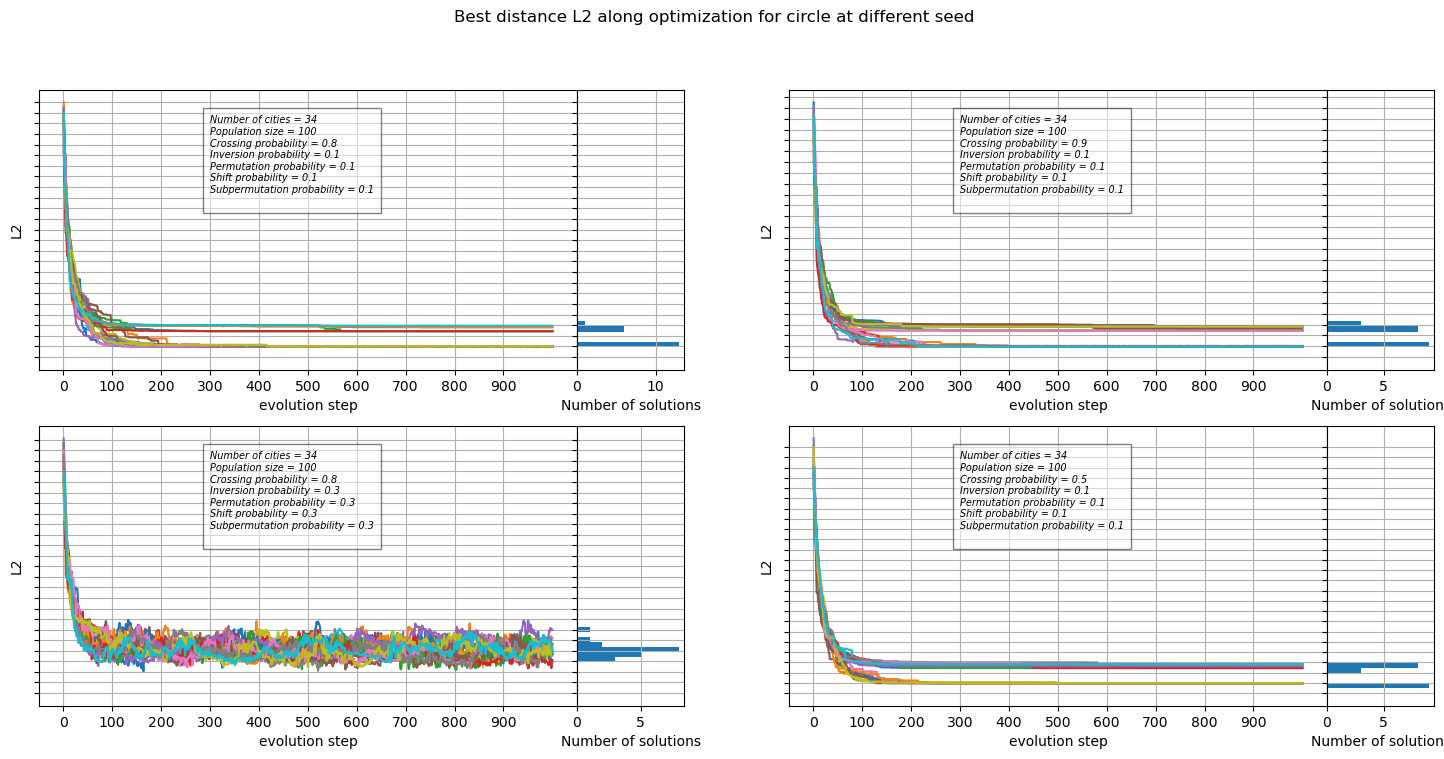

In [19]:
print_best_res(["OUTPUT/circle_setup1/", "OUTPUT/circle_setup2/", "OUTPUT/circle_setup3/", "OUTPUT/circle_setup4/"], 
    'Best distance L2 along optimization for circle at different seed'
)


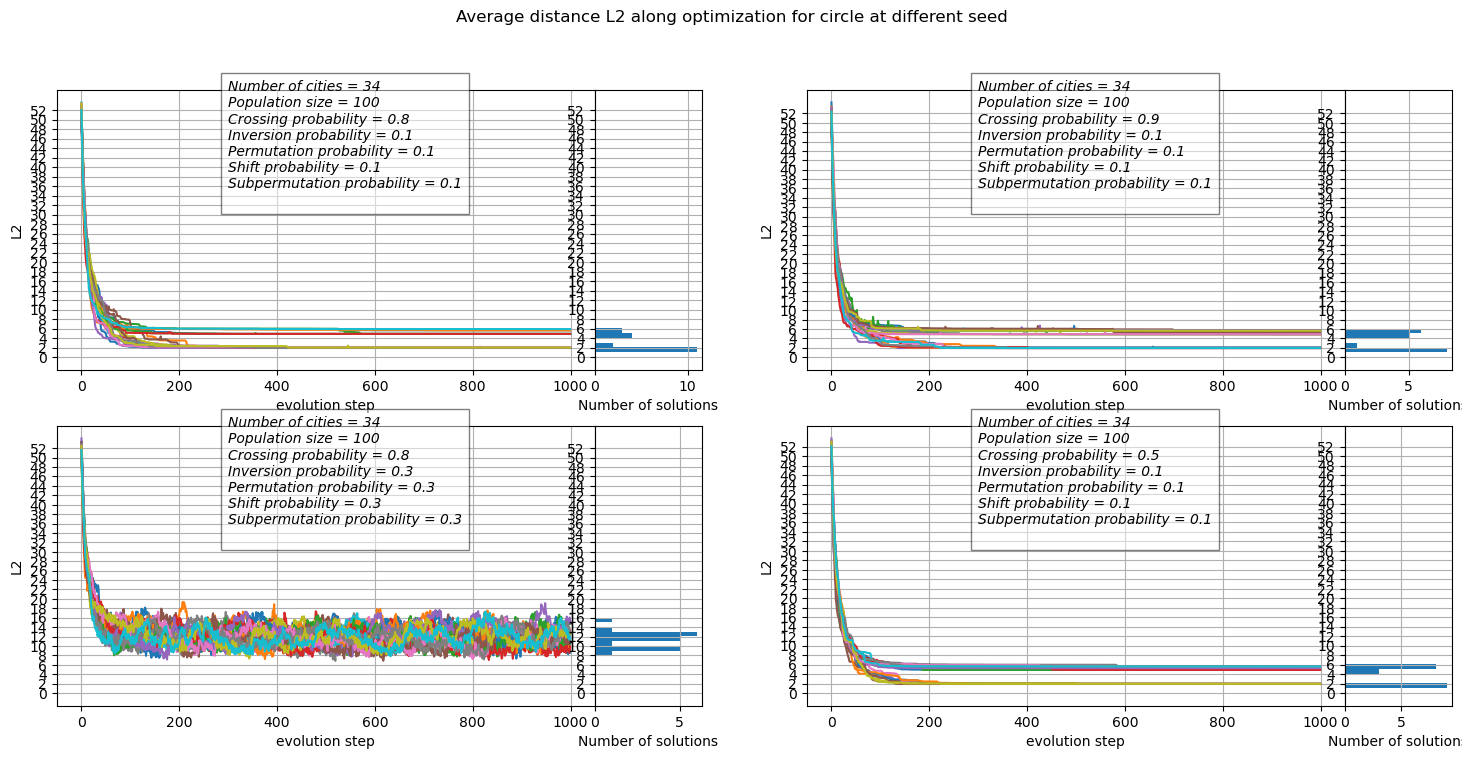

In [16]:
print_avg_res(
    ["OUTPUT/circle_setup1/", "OUTPUT/circle_setup2/","OUTPUT/circle_setup3/","OUTPUT/circle_setup4/"],
    'Average distance L2 along optimization for circle at different seed'
    )

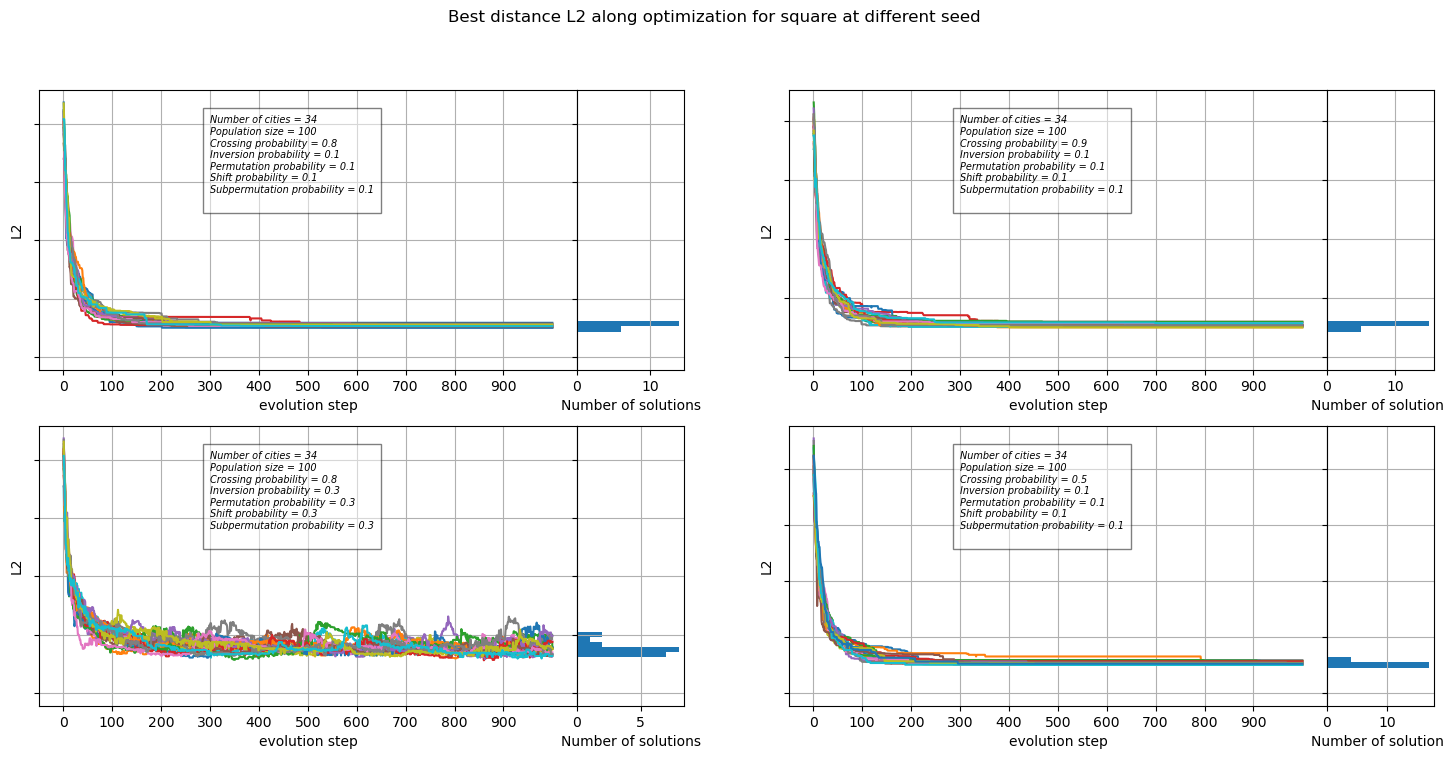

In [20]:
print_best_res(["OUTPUT/square_setup1/", "OUTPUT/square_setup2/", "OUTPUT/square_setup3/", "OUTPUT/square_setup4/"], 
    'Best distance L2 along optimization for square at different seed',
    coordfile='coord_SQUARE_34cities.dat'
)


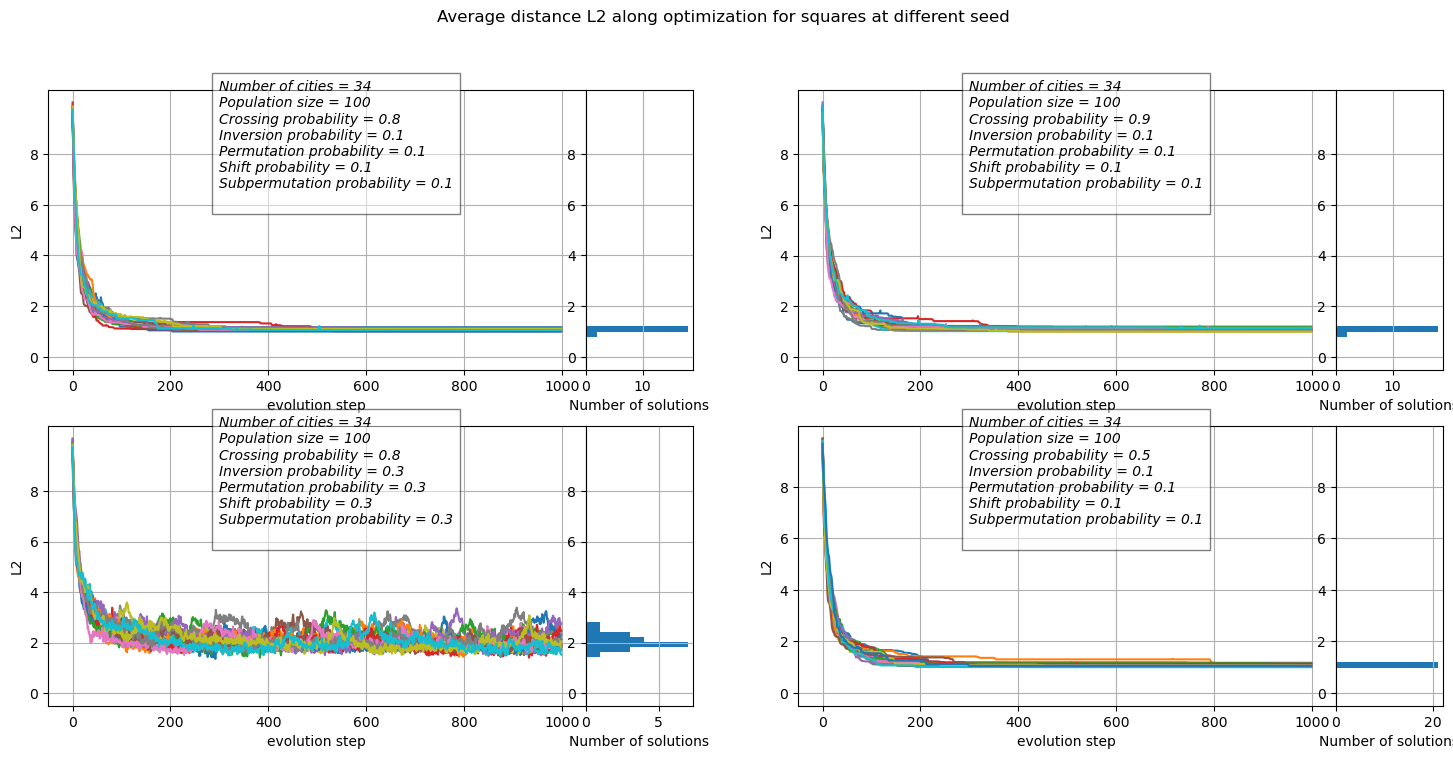

In [17]:
print_avg_res(
    ["OUTPUT/square_setup1/", "OUTPUT/square_setup2/", "OUTPUT/square_setup3/","OUTPUT/square_setup4/"],
    'Average distance L2 along optimization for squares at different seed',
    coordfile='coord_SQUARE_34cities.dat'

    )

/tmp/ipykernel_4583/1816733751.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


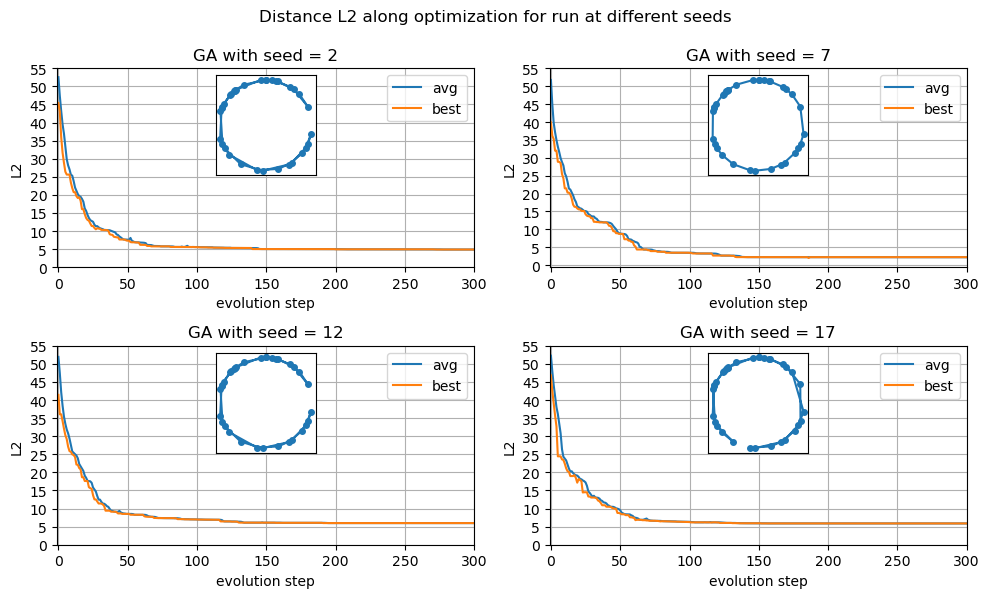

In [21]:
Nseed=20

n=2
fig, ax = plt.subplots(Nseed//(5*n), n, figsize=(5*n, 3*n))
fig.suptitle('Distance L2 along optimization for run at different seeds', y=0.99)
data_dir = "OUTPUT/circle_setup1/"


for ind, seed in enumerate(range(2,21, 5)):
    ax[ind//n, ind%n].set_title(f'GA with seed = {seed}')
    df_avg = pd.read_csv(data_dir+f'avg_circle_seed{seed}.dat', names=['avg'], skiprows=1)
    ax[ind//n, ind%n].plot(df_avg.index, df_avg['avg'], '-', label = f"avg") 

    df_best = pd.read_csv(data_dir+f'best_sol_circle_seed{seed}.dat', names=[f'city{k}' for k in range(35)]+['dist'], skiprows=1)
    ax[ind//n, ind%n].plot(df_best.index, df_best['dist'], '-', label = f"best") 

    ax[ind//n, ind%n].set_yticks(range(0, 60, 5), range(0, 60, 5))
    ax[ind//n, ind%n].grid()
    ax[ind//n, ind%n].legend()
    ax[ind//n, ind%n].set_xlabel('evolution step')
    ax[ind//n, ind%n].set_ylabel('L2')
    
    ax[ind//n, ind%n].set_xlim([-1, 300])
   
    sub_ax = inset_axes(
        parent_axes=ax[ind//n, ind%n],
        width=1,#"40%",
        height=1,#"40%",
        loc='upper center',
        borderpad=0.5  # padding between parent and inset axes
    )

    x=np.array([circle_coord.iloc[int(k)-1].x for k in df_best.iloc[len(df_best)-1][:-1].array])
    y=np.array([circle_coord.iloc[int(k)-1].y for k in df_best.iloc[len(df_best)-1][:-1].array])

    sub_ax.plot(x, y, '-o', ms=4)
    sub_ax.get_xaxis().set_visible(False)
    sub_ax.get_yaxis().set_visible(False)
plt.savefig(data_dir+'seed_distances.png', dpi=300)
plt.tight_layout()
plt.show()

/tmp/ipykernel_4583/1868392082.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


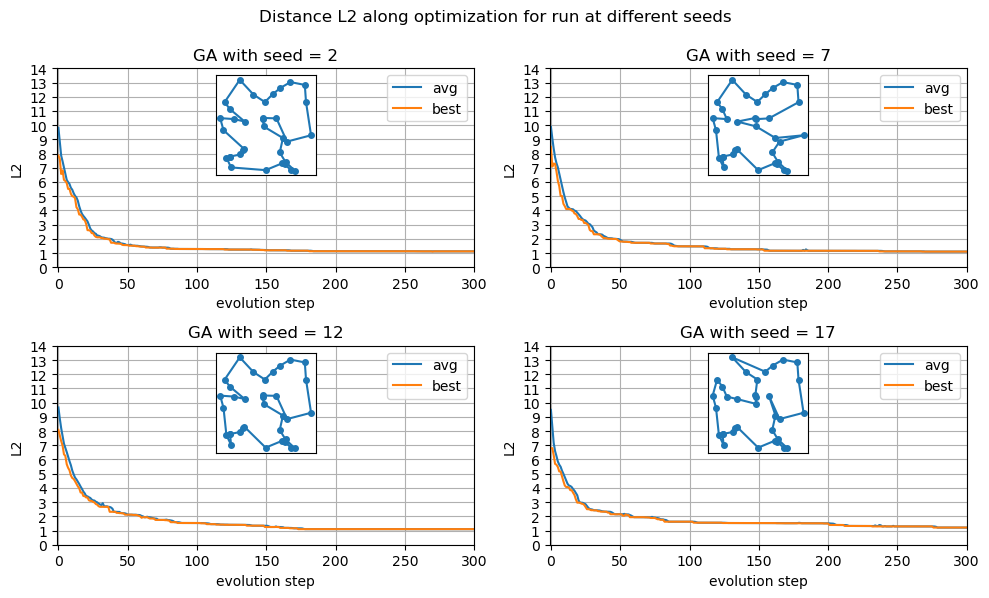

In [22]:
Nseed=20

n=2
fig, ax = plt.subplots(Nseed//(5*n), n, figsize=(5*n, 3*n))
fig.suptitle('Distance L2 along optimization for run at different seeds', y=0.99)
data_dir = "OUTPUT/square_setup1/"


for ind, seed in enumerate(range(2,21, 5)):
    ax[ind//n, ind%n].set_title(f'GA with seed = {seed}')
    df_avg = pd.read_csv(data_dir+f'avg_square_seed{seed}.dat', names=['avg'], skiprows=1)
    ax[ind//n, ind%n].plot(df_avg.index, df_avg['avg'], '-', label = f"avg") 

    df_best = pd.read_csv(data_dir+f'best_sol_square_seed{seed}.dat', names=[f'city{k}' for k in range(35)]+['dist'], skiprows=1)
    ax[ind//n, ind%n].plot(df_best.index, df_best['dist'], '-', label = f"best") 

    ax[ind//n, ind%n].set_yticks(range(0, 15), range(0, 15))
    ax[ind//n, ind%n].grid()
    ax[ind//n, ind%n].legend()
    ax[ind//n, ind%n].set_xlim([-1, 300])
    ax[ind//n, ind%n].set_xlabel('evolution step')
    ax[ind//n, ind%n].set_ylabel('L2')

    sub_ax = inset_axes(
        parent_axes=ax[ind//n, ind%n],
        width=1,#"40%",
        height=1,#"40%",
        loc='upper center',
        borderpad=0.5  # padding between parent and inset axes
    )

    x=np.array([square_coord.iloc[int(k)-1].x for k in df_best.iloc[len(df_best)-1][:-1].array])
    y=np.array([square_coord.iloc[int(k)-1].y for k in df_best.iloc[len(df_best)-1][:-1].array])

    sub_ax.plot(x, y, '-o', ms=4)
    sub_ax.get_xaxis().set_visible(False)
    sub_ax.get_yaxis().set_visible(False)
plt.savefig(data_dir+'seed_distances.png', dpi=300)
plt.tight_layout()
plt.show()

Scrivere qualcosa commentando e mettendo link codice per creare gif [codice gif](animation.py)

Esempio di una run che finisce trovando effettivamente il minimo assoluto e una che non riesce a generarlo



Circle seed = 1             |  Circle seed = 2
:-------------------------:|:-------------------------:
![SegmentLocal](OUTPUT/gifs/animation_circle_seed1.gif "segment") | ![SegmentLocal](OUTPUT/gifs/animation_circle_seed6.gif "segment")


Square seed = 1             |  Square seed = 2
:-------------------------:|:-------------------------:
![SegmentLocal](OUTPUT/gifs/animation_square_seed1.gif "segment") | ![SegmentLocal](OUTPUT/gifs/animation_square_seed6.gif "segment")
